# Diverse Molecule Sampling

This notebook implements clustering-based diverse molecule sampling from SMILES files.

In [6]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Main Function: Sample Diverse Molecules

The function uses clustering-based selection to find k diverse molecules from a SMILES file.

In [7]:
def sample_diverse_molecules(smiles_file_path, k, fingerprint_radius=2, n_bits=2048, random_state=42):
    """
    Sample k diverse molecules from a SMILES file using clustering-based selection.
    
    Parameters:
    -----------
    smiles_file_path : str
        Path to txt file with one SMILES string per line
    k : int
        Number of diverse molecules to sample
    fingerprint_radius : int, default=2
        Radius for Morgan fingerprints (2 = ECFP4)
    n_bits : int, default=2048
        Number of bits in fingerprint
    random_state : int, default=42
        Random seed for reproducibility
        
    Returns:
    --------
    selected_smiles : list
        List of k SMILES strings representing diverse molecules
    selected_indices : list
        List of indices in the original file
    fingerprints_array : np.ndarray
        Array of all fingerprints (for visualization)
    cluster_labels : np.ndarray
        Cluster assignment for each molecule
    """
    
    # Read SMILES from file
    print(f"Reading SMILES from {smiles_file_path}...")
    smiles_list = []
    with open(smiles_file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:  # Skip empty lines
                smiles_list.append(line)
    
    print(f"Read {len(smiles_list)} SMILES strings")
    
    # Parse SMILES and generate fingerprints
    print("Generating molecular fingerprints...")
    valid_smiles = []
    valid_indices = []
    fingerprints = []
    
    for idx, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            # Generate Morgan fingerprint
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, fingerprint_radius, nBits=n_bits)
            fingerprints.append(np.array(fp))
            valid_smiles.append(smiles)
            valid_indices.append(idx)
        else:
            print(f"Warning: Invalid SMILES at line {idx}: {smiles}")
    
    print(f"Successfully parsed {len(valid_smiles)} valid molecules")
    
    # Check if k is valid
    if k > len(valid_smiles):
        print(f"Warning: Requested k={k} is greater than number of valid molecules ({len(valid_smiles)})")
        print(f"Adjusting k to {len(valid_smiles)}")
        k = len(valid_smiles)
    
    # Convert fingerprints to numpy array
    fingerprints_array = np.array(fingerprints)
    
    # Perform k-means clustering
    print(f"Performing k-means clustering with k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    cluster_labels = kmeans.fit_predict(fingerprints_array)
    
    # Select representative molecule from each cluster (closest to centroid)
    print("Selecting representative molecules from each cluster...")
    selected_smiles = []
    selected_indices = []
    selected_fp_indices = []  # Indices in the fingerprint array for visualization
    
    for cluster_id in range(k):
        # Find all molecules in this cluster
        cluster_mask = cluster_labels == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        if len(cluster_indices) == 0:
            continue
            
        # Get fingerprints for this cluster
        cluster_fps = fingerprints_array[cluster_mask]
        
        # Find molecule closest to centroid
        centroid = kmeans.cluster_centers_[cluster_id]
        distances = np.linalg.norm(cluster_fps - centroid, axis=1)
        closest_idx = cluster_indices[np.argmin(distances)]
        
        selected_smiles.append(valid_smiles[closest_idx])
        selected_indices.append(valid_indices[closest_idx])
        selected_fp_indices.append(closest_idx)  # Track position in fingerprint array
    
    print(f"Selected {len(selected_smiles)} diverse molecules")
    
    return selected_smiles, selected_indices, fingerprints_array, cluster_labels, selected_fp_indices

In [8]:
def calculate_diversity_metrics(smiles_list, fingerprint_radius=2, n_bits=2048):
    """
    Calculate diversity metrics for a set of molecules.
    
    Parameters:
    -----------
    smiles_list : list
        List of SMILES strings
    fingerprint_radius : int, default=2
        Radius for Morgan fingerprints
    n_bits : int, default=2048
        Number of bits in fingerprint
        
    Returns:
    --------
    avg_tanimoto_distance : float
        Average pairwise Tanimoto distance (1 - Tanimoto similarity)
    """
    from rdkit import DataStructs
    
    # Generate fingerprints
    fps = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, fingerprint_radius, nBits=n_bits)
            fps.append(fp)
    
    # Calculate pairwise Tanimoto distances
    n = len(fps)
    if n < 2:
        return 0.0
    
    distances = []
    for i in range(n):
        for j in range(i+1, n):
            similarity = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            distance = 1 - similarity
            distances.append(distance)
    
    avg_distance = np.mean(distances)
    return avg_distance

## Example Usage

Sample diverse molecules from the robin_smiles.txt file.

In [9]:
# Example: Sample 10 diverse molecules from robin_smiles.txt
smiles_file = "inputs/ligands/robin_smiles.txt"
k = 2000

selected_smiles, selected_indices, all_fps, cluster_labels, selected_fp_indices = sample_diverse_molecules(
    smiles_file_path=smiles_file,
    k=k,
    fingerprint_radius=2,
    n_bits=1024,
    random_state=42
)

# Display results
print("\n" + "="*60)
print(f"Selected {len(selected_smiles)} diverse molecules:")
print("="*60)
for i, (smiles, idx) in enumerate(zip(selected_smiles, selected_indices)):
    print(f"{i+1}. Index {idx}: {smiles}")

# Calculate diversity metrics
print("\n" + "="*60)
print("Diversity Metrics:")
print("="*60)
avg_distance = calculate_diversity_metrics(selected_smiles)
print(f"Average pairwise Tanimoto distance: {avg_distance:.4f}")
print(f"(Higher values indicate more diverse molecules, range: 0-1)")

Reading SMILES from inputs/ligands/robin_smiles.txt...
Read 24447 SMILES strings
Generating molecular fingerprints...


[15:39:42] Conflicting single bond directions around double bond at index 27.
[15:39:42]   BondStereo set to STEREONONE and single bond directions set to NONE.


Successfully parsed 24447 valid molecules
Performing k-means clustering with k=2000...
Selecting representative molecules from each cluster...
Selected 2000 diverse molecules

Selected 2000 diverse molecules:
1. Index 19268: [H]c1ccc(cc1)S(c1c(NCC2CCCO2)oc(c2ccccc2)n1)(=O)=O
2. Index 13121: c1cc(ccc1c1nnc(N)s1)O
3. Index 22444: C(c1ccc(cc1)F)N1c2ccccc2C2=C(C(C(C#N)=C(N)O2)c2ccc(cc2)F)S1(=O)=O
4. Index 21139: CCc1nc2ccccc2n1CC(COc1ccccc1C)O
5. Index 7643: CCCCCCCNC1CC(N(C1=O)c1ccc(cc1)[Br])=O
6. Index 3484: COc1ccc(CCCC(N2CCC(CN)C2)=O)cc1
7. Index 5051: [H]c1nc2CCNCCc2c(n1)N1CCc2c(C1)ccs2
8. Index 19413: Cc1ccccc1NCc1nnc(c2ccccc2)o1
9. Index 19891: Cc1cc(Nc2ccccc2)n2c(n1)nc(c1ccccc1)n2
10. Index 12015: CC1CC(Nc2ccccc2)N(C(C)=O)N1c1ccccc1
11. Index 16948: CCOC(c1c2ccc(c(c2sc1N)OC)[Br])=O
12. Index 11846: Cc1ccc(cc1)S(N(CC(CN1CCCCC1)O)c1ccccc1)(=O)=O
13. Index 11448: COc1ccc(cc1)c1nnc(N)o1
14. Index 15017: C(CN1C(C2C(C3c4ccccc4C2c2ccccc23)C1=O)=O)CO
15. Index 22997: C(CO[N+]([O-])=O)NC(c1

## Save Selected Molecules

Utility function to save the diverse molecules to a new file.

In [10]:
def save_molecules_to_file(smiles_list, output_path, include_indices=None):
    """
    Save SMILES strings to a text file.
    
    Parameters:
    -----------
    smiles_list : list
        List of SMILES strings to save
    output_path : str
        Path to output file
    include_indices : list, optional
        If provided, includes original indices in the output (one per line after SMILES)
    """
    with open(output_path, 'w') as f:
        if include_indices is not None:
            for smiles, idx in zip(smiles_list, include_indices):
                f.write(f"{smiles}\n")
        else:
            for smiles in smiles_list:
                f.write(f"{smiles}\n")
    
    print(f"Saved {len(smiles_list)} molecules to {output_path}")

In [11]:
# Example: Save selected diverse molecules to a file
output_file = "inputs/ligands/diverse_molecules.txt"
save_molecules_to_file(selected_smiles, output_file, include_indices=selected_indices)

print(f"\nYou can now use the diverse molecules from: {output_file}")

Saved 2000 molecules to inputs/ligands/diverse_molecules.txt

You can now use the diverse molecules from: inputs/ligands/diverse_molecules.txt


## Visualization

Visualize the chemical space and selected diverse molecules using PCA.

In [20]:
def visualize_diversity(fingerprints_array, cluster_labels, selected_indices, title="Chemical Space Diversity"):
    """
    Visualize the chemical space using PCA and highlight selected diverse molecules.
    
    Parameters:
    -----------
    fingerprints_array : np.ndarray
        Array of molecular fingerprints
    cluster_labels : np.ndarray
        Cluster assignment for each molecule
    selected_indices : list
        Indices of selected diverse molecules (in the fingerprints_array)
    title : str
        Title for the plot
    """
    # Reduce dimensionality with PCA
    pca = PCA(n_components=2, random_state=42)
    coords_2d = pca.fit_transform(fingerprints_array)
    
    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Plot all molecules colored by cluster
    scatter = ax.scatter(coords_2d[:, 0], coords_2d[:, 1], 
                        c=cluster_labels, cmap='tab10', 
                        alpha=0.3, s=20, label='All molecules')
    
    # Highlight selected diverse molecules
    selected_coords = coords_2d[selected_indices]
    ax.scatter(selected_coords[:, 0], selected_coords[:, 1], 
              c='red', marker='*', s=20, 
              edgecolors='red', linewidths=1.5,
              label='Selected diverse molecules', zorder=5, alpha=0.5)
    
    # # Add annotations for selected molecules
    # for i, idx in enumerate(selected_indices):
    #     ax.annotate(f'{i+1}', 
    #                (coords_2d[idx, 0], coords_2d[idx, 1]),
    #                xytext=(5, 5), textcoords='offset points',
    #                fontsize=9, fontweight='bold',
    #                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.colorbar(scatter, ax=ax, label='Cluster ID')
    plt.tight_layout()
    plt.show()
    
    print(f"PCA explains {pca.explained_variance_ratio_.sum():.2%} of total variance")

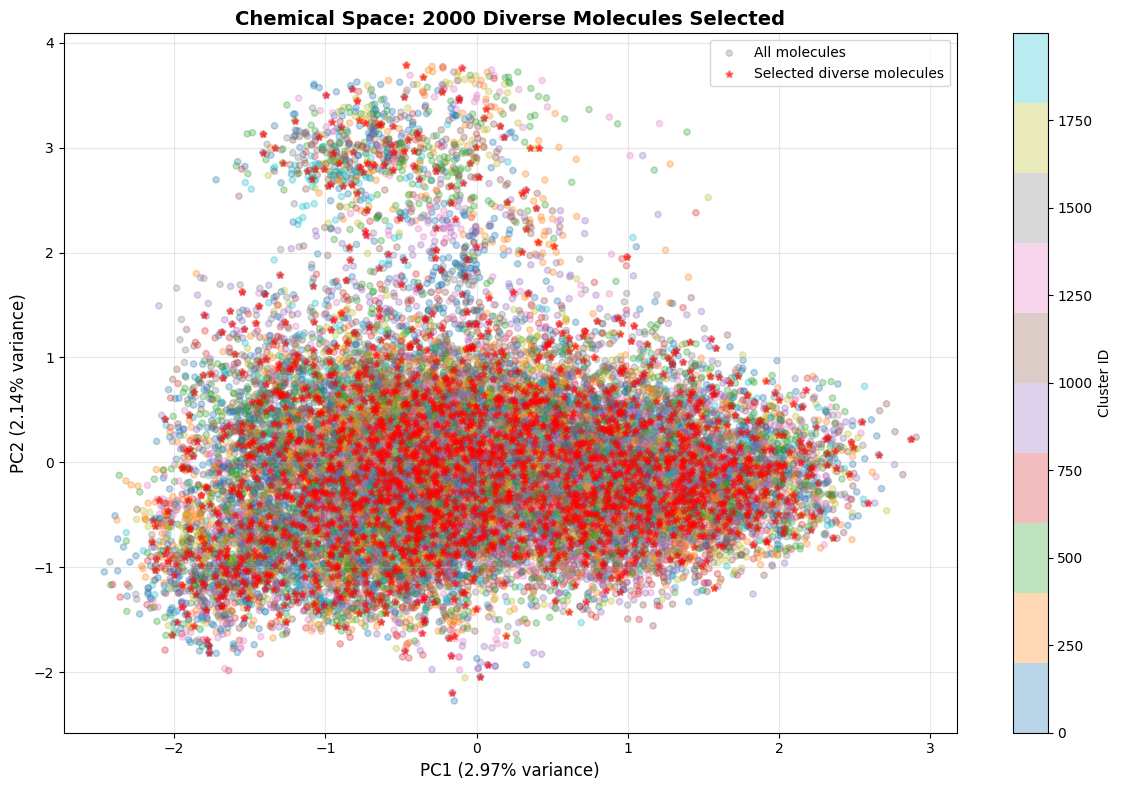

PCA explains 5.12% of total variance


In [21]:
# Visualize the chemical space and selected diverse molecules
visualize_diversity(all_fps, cluster_labels, selected_fp_indices, 
                   title=f"Chemical Space: {k} Diverse Molecules Selected")

## Comparison with Random Sampling

Compare the diversity of clustering-based selection vs random sampling.

In [ ]:
# Compare with random sampling
print("Comparing clustering-based selection vs random sampling...")
print("="*60)

# Read and randomly sample molecules
with open(smiles_file, 'r') as f:
    all_smiles = [line.strip() for line in f if line.strip()]

# Random sample
random_indices = np.random.choice(len(all_smiles), k, replace=False)
random_smiles = [all_smiles[i] for i in random_indices]

# Calculate diversity for both
clustered_diversity = calculate_diversity_metrics(selected_smiles)
random_diversity = calculate_diversity_metrics(random_smiles)

print(f"Clustering-based diversity: {clustered_diversity:.4f}")
print(f"Random sampling diversity:  {random_diversity:.4f}")
print(f"Improvement: {((clustered_diversity - random_diversity) / random_diversity * 100):.2f}%")
print("\nClustering-based selection typically produces more diverse sets!")

## Additional Usage Examples

### Example 1: Sample different number of molecules

In [ ]:
# Example: Sample 50 diverse molecules
k_large = 50

selected_smiles_50, selected_indices_50, all_fps_50, cluster_labels_50, selected_fp_indices_50 = sample_diverse_molecules(
    smiles_file_path=smiles_file,
    k=k_large,
    fingerprint_radius=2,
    n_bits=2048,
    random_state=42
)

print(f"\nSelected {len(selected_smiles_50)} diverse molecules")
diversity_50 = calculate_diversity_metrics(selected_smiles_50)
print(f"Average pairwise Tanimoto distance: {diversity_50:.4f}")

### Example 2: Use with custom SMILES file

In [ ]:
# Example with a different file
# Uncomment and modify the path to use with your own SMILES file
# custom_file = "path/to/your/smiles.txt"
# k_custom = 20
# 
# selected_custom, indices_custom, fps_custom, labels_custom, fp_indices_custom = sample_diverse_molecules(
#     smiles_file_path=custom_file,
#     k=k_custom,
#     fingerprint_radius=2,
#     n_bits=2048,
#     random_state=42
# )
# 
# # Save results
# save_molecules_to_file(selected_custom, "outputs/diverse_custom.txt")
# 
# # Visualize
# visualize_diversity(fps_custom, labels_custom, fp_indices_custom, 
#                    title=f"Custom Dataset: {k_custom} Diverse Molecules")

print("Uncomment the code above to use with your custom SMILES file")